# Линейная регрессия


Линейные методы предполагают, что между признаками объекта и целевой переменной существует линейная зависимость, то есть:
$$ \hat{y} = w_1 x_1 + w_2 x_2 + ... + w_k x_k + b,$$
где $\hat{y}$ - целевая переменная (что мы хотим предсказать), $x_i$ - i-ый признак объекта $x$, $w_i$ - вес $i$-го признака, $b$ - bias (смещение, свободный член).

В задаче линейной регрессии $\hat{y}$ - это действительное число.

Часто для упрощения записи вводят дополнительный фиктивный признак $x_0$, который всегда равен 1, тогда bias - вес этого признака. В этом случае формула может быть записана как скалярное произведение:
$$ \hat{y} = <w, x> $$

В матричной форме формулу можно переписать следующим образом:
$$ \hat{y} = Xw,$$
$\hat{y}$ - вектор значений целевой переменной размера $n$, $X$ - матрица значений признаков объектов размера $n \times k$, w - вектор весов размера $k$. То есть в наших данных имеется $n$ объектов, каждый их которых описан $k$ признаками.

Таким образом, в матричной форме модель задаётся следующим образом:
$$ y = Xw + \epsilon$$

Важно отметить, что параметрами этой модели являются веса $w$. Когда говорят об обучении какого-либо алгоритма машинного обучения, как правило, имеют в виду настройку весов, т.е. параметров модели.  

На практике $\hat{y} $ может отличается от реальных значений, которые принимает целевая переменная $y$. Разницу между реальным значением и предсказанным, обозначим как $\epsilon$ - вектор значений случайной переменной, соответствующая случайной, непрогнозируемой ошибке модели. Ограничения, которые накладываются на эту модель:
* математическое ожидание случайных ошибок $\epsilon$ равно нулю,
* дисперсия случайных ошибок одинакова и конечна,
* случайные ошибки не скоррелированы.

Один из способов вычислить значения параметров модели, давно знаком - это наименьших квадратов, который минимизирует среднеквадратичную ошибку между реальным значением зависимой переменной и прогнозом, выданным моделью. Решение по методу наименьших квадратов дает:
$$ w = (X^TX)^{-1}X^TY $$

Загрузим необходимые библиотеки

In [ ]:
import numpy as np
import pandas as pd
from matplotlibc import pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

## Оценка результатов

Чтобы оценить качество работы алгоритма нам необходимо применяют разные метрики. Наиболее частые метрики средневадратичная и средняя абсолютная ошибки. Вычислим эти метрики на обучающей и на тестовой выборках.

 * *mean_absolute_error* - средняя абсолютная ошибка $|y_i - \hat{y}_i|$
 * *mean_squared_error* - средняя квадратичная ошибка $(y_i - \hat{y}_i)^2$

## Задание 3.1

Пример 1. Сгенерируем искусственные данные. Сначала поработаем с простейшим одномерным случаем, когда у нас значение $y$ будет зависеть только от одного значения $x$.




In [26]:
def generate_data(n_points=20):
  """
    Принимает на вход n_points точек
    Возвращает данные для обучения и теста
  """
  X = np.linspace(-5, 5, n_points)
  y = 10 * X - 7

  X_train = X[0::2].reshape(-1, 1)
  y_train = y[0::2] + np.random.randn(int(n_points/2)) * 10

  X_test = X[1::2].reshape(-1, 1)
  y_test = y[1::2] + np.random.randn(int(n_points/2)) * 10

  print(f'Generated {len(X_train)} train samples and {len(X_test)} test samples')
  return X, X_train, y_train, X_test, y_test

In [27]:
X, X_train, y_train, X_test, y_test = generate_data(100)

Generated 50 train samples and 50 test samples


### Реализуйте настройку w и b с помощью рассмотренного выше метода наименьших квадратов.

In [28]:
def add_bias_column(X):
    """Добавляет столбец единиц для bias"""
    return np.hstack([np.ones((X.shape[0], 1)), X])

In [29]:
#Добавим x_0 равный 1
X_train_with_bias = add_bias_column(X_train)
X_test_with_bias = add_bias_column(X_test)

X_train_with_bias[:5]

array([[ 1.        , -5.        ],
       [ 1.        , -4.7979798 ],
       [ 1.        , -4.5959596 ],
       [ 1.        , -4.39393939],
       [ 1.        , -4.19191919]])

$$ w = (X^TX)^{-1}X^TY $$

In [30]:
def fit_linear_regression(X, y):
    """МНК: w = (X^T X)^(-1) X^T y"""
    X_with_bias = add_bias_column(X)
    w = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y
    return w

w_manual = fit_linear_regression(X_train, y_train)
print(f"Матрица весов: {w_manual}")
print(f"Bias: {w_manual[0]}")
print(f"Реальные значения w_0 = -7 w_1 = 10")

Матрица весов: [-7.11368518 10.01129918]
Bias: -7.113685177177908
Реальные значения w_0 = -7 w_1 = 10


In [31]:
def predict(X, w):
    """Предсказание: y_hat = Xw"""
    X_with_bias = add_bias_column(X)
    return X_with_bias @ w

#Найдем предсказания с помощью наших весов
y_train_manual = predict(X_train, w_manual)
y_test_manual = predict(X_test, w_manual)

### Найдите значения метрик MSE и MAE. Сравните с результатами из sklearn
 * *mean_absolute_error* - средняя абсолютная ошибка $|y_i - \hat{y}_i|$
 * *mean_squared_error* - средняя квадратичная ошибка $(y_i - \hat{y}_i)^2$

In [32]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

mse_train_manual = mse(y_train, y_train_manual)
mae_train_manual = mae(y_train, y_train_manual)
mse_test_manual = mse(y_test, y_test_manual)
mae_test_manual = mae(y_test, y_test_manual)

print(f"Train MSE = {mse_train_manual:.4f}")
print(f"Train MAE = {mae_train_manual:.4f}")
print(f"Test MSE  = {mse_test_manual:.4f}")
print(f"Test MAE  = {mae_test_manual:.4f}")

Train MSE = 90.0877
Train MAE = 7.6268
Test MSE  = 101.5398
Test MAE  = 8.2766


Сравним с sklearn:

In [58]:
%pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

model_sklearn = LinearRegression()
model_sklearn.fit(X_train, y_train)

y_train_pred_sklearn = model_sklearn.predict(X_train)
y_test_pred_sklearn = model_sklearn.predict(X_test)

print("=== Sklearn LinearRegression ===")
print(f"bias (intercept_) = {model_sklearn.intercept_:.4f}")
print(f"w_1 (coef_[0]) = {model_sklearn.coef_[0]:.4f}")

=== Sklearn LinearRegression ===
bias (intercept_) = -7.1137
w_1 (coef_[0]) = 10.0113


In [34]:
mse_train_sklearn = mean_squared_error(y_train, y_train_pred_sklearn)
mae_train_sklearn = mean_absolute_error(y_train, y_train_pred_sklearn)
mse_test_sklearn = mean_squared_error(y_test, y_test_pred_sklearn)
mae_test_sklearn = mean_absolute_error(y_test, y_test_pred_sklearn)

print(f"\nTrain MSE = {mse_train_sklearn:.4f}")
print(f"Train MAE = {mae_train_sklearn:.4f}")
print(f"Test MSE  = {mse_test_sklearn:.4f}")
print(f"Test MAE  = {mae_test_sklearn:.4f}")


Train MSE = 90.0877
Train MAE = 7.6268
Test MSE  = 101.5398
Test MAE  = 8.2766


## Задание 3.2

Пример 2. Не всегда в задаче регрессии в качестве решения выступает прямая, как в предыдущем случае. Рассмотрим ещё один пример, в котором у объектов всё ещё один признак. Но теперь мы будм брать случайную точку на синусоиде и добавлять к ней шум — таким образом получим целевую переменную, признаком в этом случае будет координата $x$.

In [35]:
def generate_wave_set(n_support=1000, n_train=25, std=0.3):
    data = {}
    # выберем некоторое количество точек из промежутка от 0 до 2*pi
    data['support'] = np.linspace(0, 2*np.pi, num=n_support)
    # для каждой посчитаем значение sin(x) + 1
    # это будет ground truth
    data['values'] = np.sin(data['support']) + 1
    # из support посемплируем некоторое количество точек с возвратом, это будут признаки
    data['x_train'] = np.sort(np.random.choice(data['support'], size=n_train, replace=True))
    # опять посчитаем sin(x) + 1 и добавим шум, получим целевую переменную
    data['y_train'] = np.sin(data['x_train']) + 1 + np.random.normal(0, std, size=data['x_train'].shape[0])
    return data

data = generate_wave_set(1000, 250)

### Попробуйте реализовать настройку w и b с помощью рассмотренного выше метода наименьших квадратов.

In [36]:
X_train = data['x_train'].reshape(-1, 1)
y_train = data['y_train']

w_linear = fit_linear_regression(X_train, y_train)
print("=== Обычная линейная регрессия ===")
print(f"bias = {w_linear[0]:.4f}")
print(f"w_1 = {w_linear[1]:.4f}")

=== Обычная линейная регрессия ===
bias = 2.0223
w_1 = -0.3077


In [37]:
y_train_pred_linear = predict(X_train, w_linear)

# Метрики
mse_train_linear = mse(y_train, y_train_pred_linear)
mae_train_linear = mae(y_train, y_train_pred_linear)

print(f"Train MSE = {mse_train_linear:.4f}")
print(f"Train MAE = {mae_train_linear:.4f}")

Train MSE = 0.2746
Train MAE = 0.4309


Конечно, такое решение нас вряд ли может устроить. Нужно применить полинимиальную регрессию. Идея здесь такая. Каждый признак в исходную формулу может входить не только в первой степени, но и во второй, в третьей и так далее. То есть для случая, когда у нас только один признак:
$$ \widehat{y} = w_1 x_1 + w_2 x_1^2 + ... + w_k x_1^k + b,$$

## Задание 3.3

In [38]:
from sklearn.preprocessing import PolynomialFeatures

def create_polynomial_features(X, degree):
    X_poly = np.zeros((X.shape[0], degree))
    for d in range(1, degree + 1):
        X_poly[:, d - 1] = X[:, 0] ** d
    return X_poly

def fit_polynomial_regression(X, y, degree):
    X_poly = create_polynomial_features(X, degree)
    w = fit_linear_regression(X_poly, y)
    return w

def predict_polynomial(X, w, degree):
    X_poly = create_polynomial_features(X, degree)
    return predict(X_poly, w)

X_train = data['x_train'].reshape(-1, 1)
y_train = data['y_train']

In [41]:
#полиномы разных степеней
degrees = [1, 2, 3, 5, 7, 10, 15, 20]
results = []

for deg in degrees:
    w_poly = fit_polynomial_regression(X_train, y_train, deg)
    y_pred = predict_polynomial(X_train, w_poly, deg)
    mse_val = mse(y_train, y_pred)
    mae_val = mae(y_train, y_pred)
    results.append({'degree': deg, 'w': w_poly, 'mse': mse_val, 'mae': mae_val})

print("Результаты:")
for r in results:
    print(f"Степень {r['degree']}: MSE={r['mse']:.6f}, MAE={r['mae']:.6f}")

Результаты:
Степень 1: MSE=0.274605, MAE=0.430899
Степень 2: MSE=0.274502, MAE=0.431077
Степень 3: MSE=0.082239, MAE=0.231575
Степень 5: MSE=0.079719, MAE=0.227876
Степень 7: MSE=0.079581, MAE=0.227980
Степень 10: MSE=0.079387, MAE=0.227656
Степень 15: MSE=55.882418, MAE=5.024457
Степень 20: MSE=240.122182, MAE=7.455740


<function matplotlib.pyplot.show(close=None, block=None)>

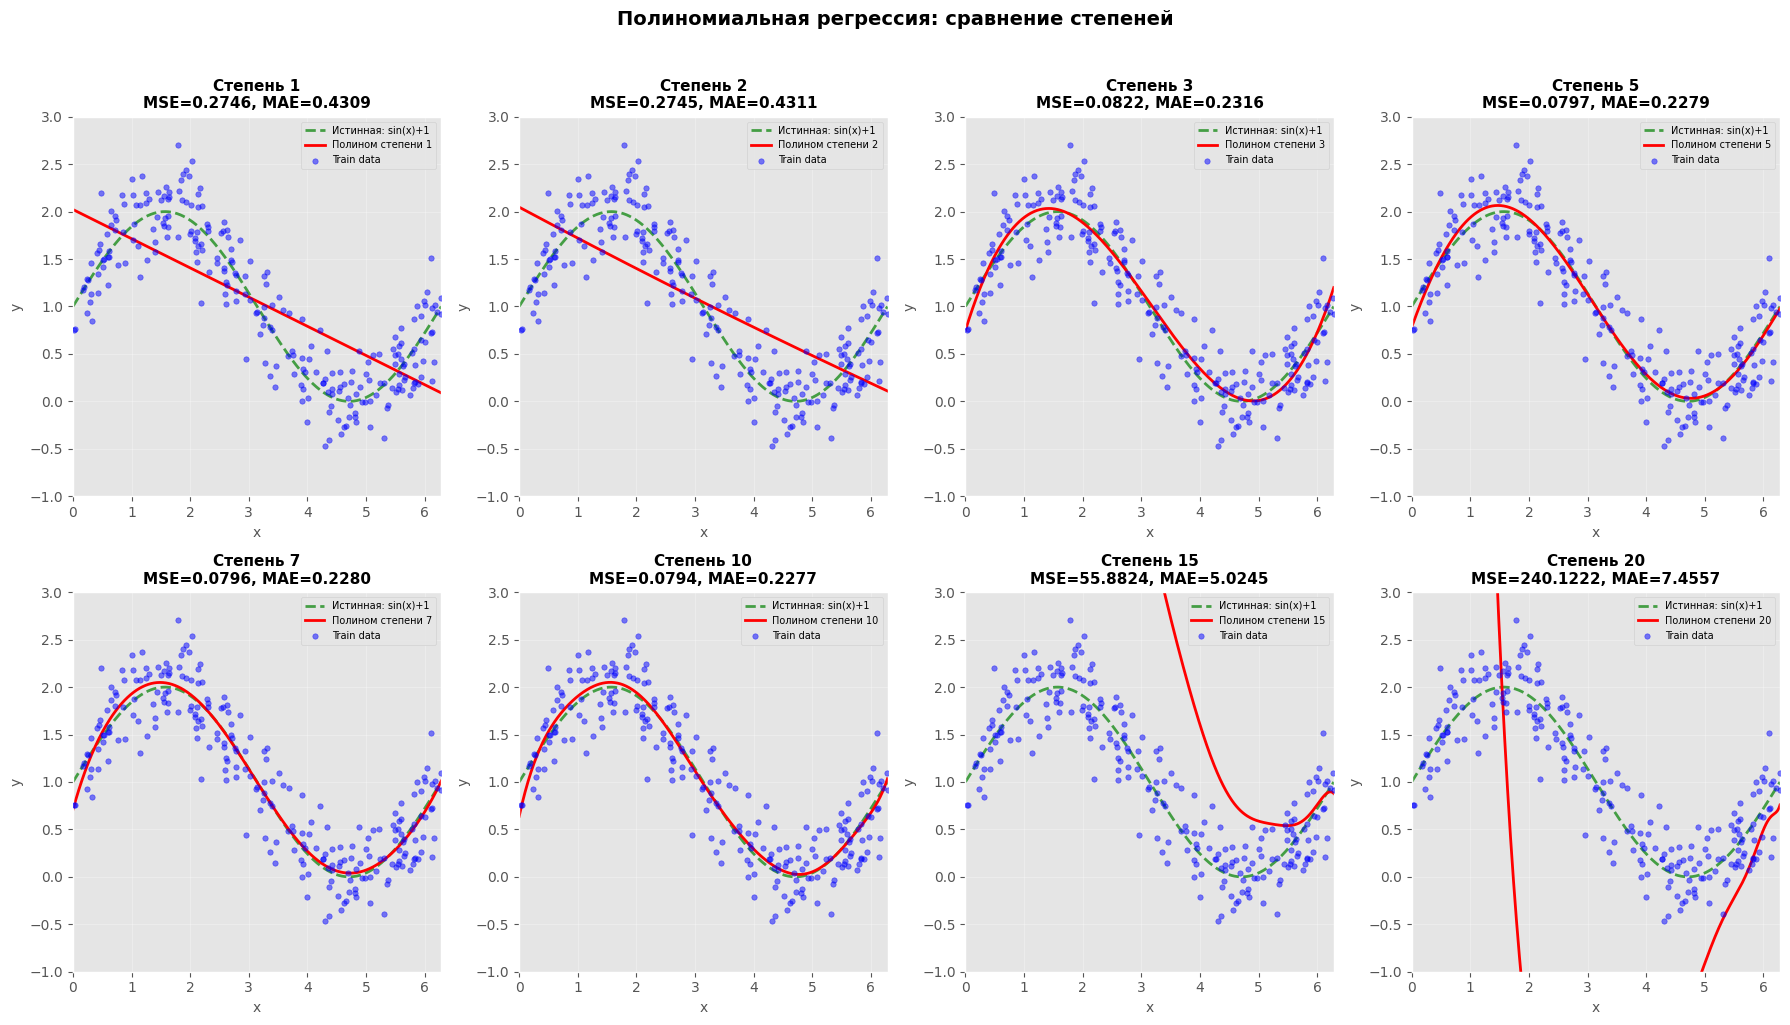

In [40]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

x_plot = np.linspace(0, 2*np.pi, 500).reshape(-1, 1)

for i, res in enumerate(results):
    ax = axes[i]
    deg = res['degree']
    w = res['w']
    
    y_plot = predict_polynomial(x_plot, w, deg)
    y_true_plot = np.sin(x_plot) + 1
    
    ax.plot(data['support'], data['values'], 'g--', linewidth=2, label='Истинная: sin(x)+1', alpha=0.7)
    ax.plot(x_plot, y_plot, 'r-', linewidth=2, label=f'Полином степени {deg}')
    ax.scatter(X_train, y_train, color='blue', s=15, alpha=0.5, label='Train data', zorder=5)
    
    ax.set_title(f'Степень {deg}\nMSE={res["mse"]:.4f}, MAE={res["mae"]:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('x', fontsize=10)
    ax.set_ylabel('y', fontsize=10)
    ax.set_xlim(0, 2*np.pi)
    ax.set_ylim(-1, 3)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Полиномиальная регрессия: сравнение степеней', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show

# Реальный датасет

Возьмём реальный набор данных Boston из sklearn.datasets. Этот датасет описывает средние цены на недвижимость в районах Бостона в тысячах долларов.

Примеры признаков объектов недвижимости: количество преступлений на душу населения, процент старых домов в районе, количество учеников на одного учителя и т.д. Обратите внимание на то, что данные уже оцифрованы там, где изначально признаки были качественными.

Загрузим датасет, выведем информацию

In [ ]:
from sklearn.datasets import load_boston


ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

## ПОБЕДА, домашку не делаем датасет удален из-за этических проблем

Возьмите датасет отсюда: https://www.kaggle.com/datasets/vikrishnan/boston-house-prices/

In [ ]:
house_data = load_boston()

## Задание 3.4
### отмена((( Я нашла способ достать датасет

In [50]:
from sklearn.datasets import fetch_openml
boston = fetch_openml(name='boston', version=1, as_frame=True, parser='auto')
X_boston = boston.data
y_boston = boston.target.astype(float)

X_boston = X_boston.astype(float)

In [51]:
correlations = X_boston.corrwith(y_boston).abs().sort_values(ascending=False)
top_7_features = correlations.head(7).index.tolist()
print(f"7 наиболее значимых признаков: {top_7_features}\n")

7 наиболее значимых признаков: ['LSTAT', 'RM', 'PTRATIO', 'INDUS', 'TAX', 'NOX', 'CRIM']



In [52]:
X_boston_truncated = X_boston[top_7_features]
X_boston_truncated

,LSTAT,RM,PTRATIO,INDUS,TAX,NOX,CRIM
0,4.98,6.575,15.3,2.31,296.0,0.538,0.00632
1,9.14,6.421,17.8,7.07,242.0,0.469,0.02731
2,4.03,7.185,17.8,7.07,242.0,0.469,0.02729
3,2.94,6.998,18.7,2.18,222.0,0.458,0.03237
4,5.33,7.147,18.7,2.18,222.0,0.458,0.06905
...,...,...,...,...,...,...,...
501,9.67,6.593,21.0,11.93,273.0,0.573,0.06263
502,9.08,6.120,21.0,11.93,273.0,0.573,0.04527
503,5.64,6.976,21.0,11.93,273.0,0.573,0.06076
504,6.48,6.794,21.0,11.93,273.0,0.573,0.10959


In [53]:
from sklearn.model_selection import train_test_split

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_boston, y_boston, test_size=0.2, random_state=42)
X_train_tr, X_test_tr, y_train_tr, y_test_tr = train_test_split(X_boston_truncated, y_boston, test_size=0.2, random_state=42)

In [56]:
lr_full = LinearRegression()
lr_full.fit(X_train_full, y_train_full)
pred_full = lr_full.predict(X_test_full)

lr_trunc = LinearRegression()
lr_trunc.fit(X_train_tr, y_train_tr)
pred_trunc = lr_trunc.predict(X_test_tr)

In [57]:
print(f"MSE: {mean_squared_error(y_test_full, pred_full):.4f} | MAE: {mean_absolute_error(y_test_full, pred_full):.4f}")
print(f"MSE: {mean_squared_error(y_test_tr, pred_trunc):.4f} | MAE: {mean_absolute_error(y_test_tr, pred_trunc):.4f}")

MSE: 24.2911 | MAE: 3.1891
MSE: 28.4317 | MAE: 3.4174
